<a href="https://colab.research.google.com/github/debraluna/DebraLuna_DTSC3020_Summer2026/blob/main/Luna_Homework4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

66
45
                precision    recall  f1-score   support

Did Not Enroll     0.6500    0.5000    0.5652        26
      Enrolled     0.4800    0.6316    0.5455        19

      accuracy                         0.5556        45
     macro avg     0.5650    0.5658    0.5553        45
  weighted avg     0.5782    0.5556    0.5569        45



array([0, 0, 0, 0, 1, 1, 0, 0, 1, 1])

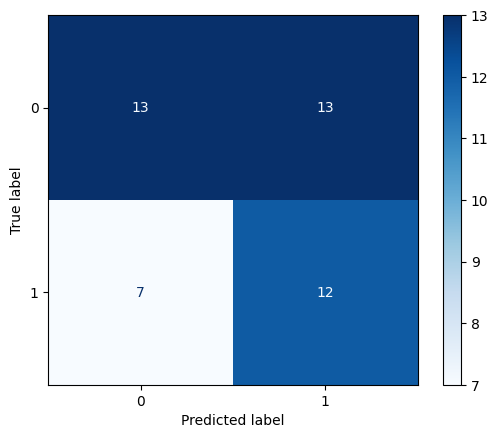

In [44]:
# Debra Luna
# Q2

import pandas as pd
from sklearn.model_selection import train_test_split

# Load the data
myData = pd.read_excel('Ch12_Q2_V05_Data_File.xlsx')
myData.head()

# Split the data (60% train, 40% test)
# Separate features (X) and target (y)
# The target variable is 'y' based on the DataFrame structure
X = myData.drop(columns=['y'])
y_data = myData['y']

X_train, X_test, y_train, y_test = train_test_split(X, y_data,
                                                    test_size=0.40,
                                                    random_state=321)

print(len(X_train))
print(len(X_test))

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Fit the scaler on the training features X
dataScaler = scaler.fit(X)

# Transform our dataScaler
X_train_std = dataScaler.transform(X_train)

X_test_std = dataScaler.transform(X_test)

# Create KNN model
from sklearn.neighbors import KNeighborsClassifier

KNN_model = KNeighborsClassifier()

# Hyperparameters
paramGrid = {'n_neighbors': range(1, 10 + 1)}

# Grid Search
from sklearn.model_selection import GridSearchCV

search = GridSearchCV(KNN_model, paramGrid, cv=10, scoring='accuracy')

# Fit
KNN_fit = search.fit(X_train_std, y_train)

pd.DataFrame(KNN_fit.cv_results_).head()

# Sort cv_results
pd.DataFrame(KNN_fit.cv_results_).sort_values('rank_test_score')[['param_n_neighbors', 'mean_test_score', 'rank_test_score']]

# Return optimal value of k
KNN_fit.best_estimator_

# Predict with k = 6
testPredictions = KNN_fit.predict(X_test_std)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, testPredictions)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(KNN_fit, X_test_std, y_test, cmap = plt.cm.Blues)

# Accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test, testPredictions)

# More Performance Measures
from sklearn.metrics import classification_report
print(classification_report(y_test, testPredictions, target_names = ['Did Not Enroll', 'Enrolled'], digits = 4))

# Changing the cutoff value
testPredictionProbs = KNN_fit.predict_proba(X_test_std)
testPredictionProbs [:10,]

import numpy as np

testPredsCustomCutoff = np.where(testPredictionProbs [:, 1] > 0.403, 1, 0)

testPredsCustomCutoff [:10]

